In [25]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

path_penguins = kagglehub.dataset_download(
    "ashkhagan/palmer-penguins-datasetalternative-iris-dataset"
)
path_wine = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path_penguins)
print("Path to dataset files:", path_wine)

Path to dataset files: /Users/anhngo/.cache/kagglehub/datasets/ashkhagan/palmer-penguins-datasetalternative-iris-dataset/versions/1
Path to dataset files: /Users/anhngo/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2


In [26]:
df_penguins = pd.read_csv(path_penguins + "/penguins.csv")
df_wine = pd.read_csv(path_wine + "/winequality-red.csv")

print("Accuracy: all correct predictions / all samples")
print("\nClassification Report:")
print("Precision: true positive / (true positive + false positive)")
print("Recall: true positive / (true positive + false negative)")
print(
    "F1-score: 2 * (precision * recall) / (precision + recall) (0 is the worst, 1 is the best)"
)
print("Support: number of actual occurrences of the class in the true_y")
print("*" * 50)

Accuracy: all correct predictions / all samples

Classification Report:
Precision: true positive / (true positive + false positive)
Recall: true positive / (true positive + false negative)
F1-score: 2 * (precision * recall) / (precision + recall) (0 is the worst, 1 is the best)
Support: number of actual occurrences of the class in the true_y
**************************************************


In [27]:
def train_and_evaluate_knn(
    X, y, n_neighbors=3, test_size=0.2, random_state=42, should_print_report=False
):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Train
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # Predict
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    # print(f"Accuracy: {accuracy:.2f}")

    if should_print_report:
        print_report(y_test, y_pred)

    return round(accuracy, 4)


def print_report(y_test, y_pred):
    # Evaluate
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# KNN on penguin dataset


In [28]:
print(df_penguins.head())
# print(df_penguins.info())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    male  
1       3800.0  female  
2       3250.0  female  
3          NaN     NaN  
4       3450.0  female  


              precision    recall  f1-score   support

      Adelie       0.70      0.90      0.79        31
   Chinstrap       0.86      0.33      0.48        18
      Gentoo       0.85      0.94      0.89        18

    accuracy                           0.76        67
   macro avg       0.80      0.73      0.72        67
weighted avg       0.78      0.76      0.73        67



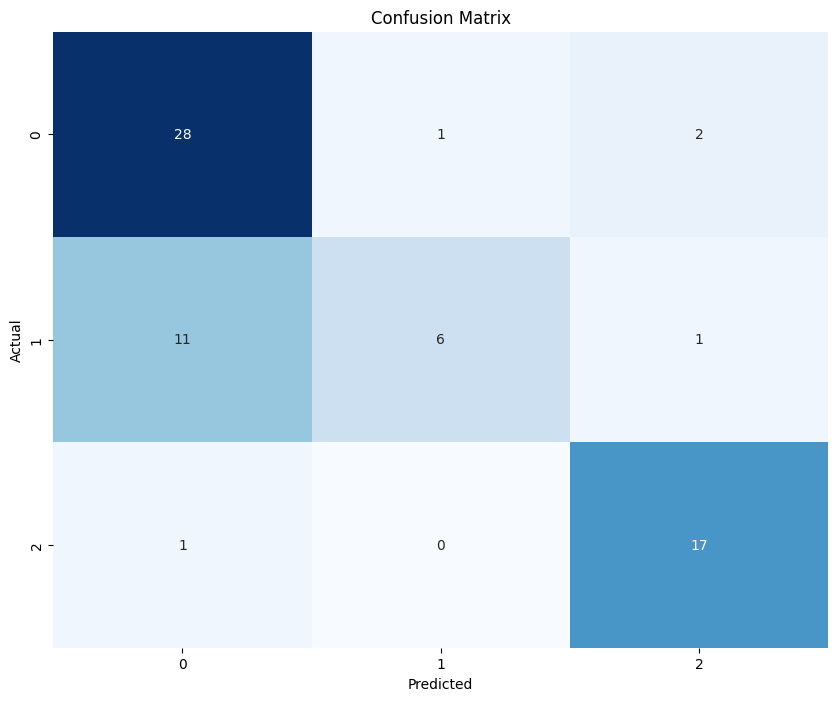

0.7612

In [29]:
from sklearn.preprocessing import LabelEncoder

df_penguins = df_penguins.dropna()
df_penguins_encoded = df_penguins.copy()

# Encode categorical columns
le_island = LabelEncoder()
le_sex = LabelEncoder()
df_penguins_encoded["island"] = le_island.fit_transform(df_penguins["island"])
df_penguins_encoded["sex"] = le_sex.fit_transform(df_penguins["sex"])

X_penguins = df_penguins_encoded.drop(columns=["species", "island", "sex"])
y_penguins = df_penguins_encoded["species"]

train_and_evaluate_knn(X_penguins, y_penguins, should_print_report=True)

In [30]:
# Evaluating k values
penguins_map = {}
for k in range(1, 21):
    score = train_and_evaluate_knn(X_penguins, y_penguins, n_neighbors=k)
    penguins_map[k] = score

sorted_items = sorted(penguins_map.items(), key=lambda item: item[1], reverse=True)
sorted_dict = dict(sorted_items)

for k, v in sorted_dict.items():
    print(f"k: {k}, v: {v}")

k: 1, v: 0.7761
k: 18, v: 0.7761
k: 3, v: 0.7612
k: 17, v: 0.7612
k: 5, v: 0.7463
k: 6, v: 0.7463
k: 7, v: 0.7463
k: 15, v: 0.7313
k: 2, v: 0.7164
k: 14, v: 0.7164
k: 19, v: 0.7164
k: 4, v: 0.7015
k: 8, v: 0.7015
k: 10, v: 0.7015
k: 13, v: 0.7015
k: 16, v: 0.7015
k: 20, v: 0.7015
k: 9, v: 0.6866
k: 11, v: 0.6866
k: 12, v: 0.6716


# KNN on wine dataset


In [35]:
print(df_wine.head())
# print(df_wine.info())
# print(df_wine.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 